# CNN Training Experiment

This notebook verifies a complete NumPy CNN on a tiny synthetic dataset and a manageable MNIST subset. The goal is to make the forward pass, backward pass, parameter updates, and learned visual features observable.

The model is intentionally small and educational:

```text
Input -> Conv (3x3, 2 filters) -> ReLU -> MaxPool -> Flatten -> Dense (10) -> Softmax
```

The MNIST section uses 2,000 training images and 500 test images. It is an educational baseline, not a state-of-the-art benchmark.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add repository root to Python path
repo_root = Path.cwd().parents[2]

sys.path.insert(0, str(repo_root))

from modules.module_01_cnn_foundations.implementations.cnn import CNN

## 2. Synthetic sanity-check dataset

A tiny random dataset is useful for checking that every layer can run end to end before spending time on MNIST. Random labels mean this section checks execution and loss bookkeeping, not meaningful generalization.

In [ ]:
np.random.seed(42)

num_samples = 10
height = 8
width = 8
channels = 1
num_classes = 10

X = np.random.randn(
    num_samples,
    height,
    width,
    channels,
)

labels = np.random.randint(
    0,
    num_classes,
    size=num_samples,
)

Y = np.zeros(
    (num_classes, num_samples)
)

Y[labels, np.arange(num_samples)] = 1

In [ ]:
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Labels:", labels)

In [ ]:
plt.imshow(X[0, :, :, 0], cmap="gray")
plt.title(f"Class: {labels[0]}")
plt.axis("off")
plt.show()

## 3. CNN initialization

The model exposes its parameter dictionary so the expected filter, bias, and dense-layer shapes can be inspected before training.

## 4. End-to-end synthetic training

This run checks that the CNN can complete forward propagation, categorical cross-entropy, backpropagation, and immediate gradient-descent updates on each sample.

In [ ]:
model = CNN(
    learning_rate=0.01,
    epochs=10,
)

In [ ]:
print(model.parameters)

## 4. Train the CNN

Train the model on the tiny synthetic dataset.

In [ ]:
model.fit(X, Y)

In [ ]:
model.loss_history

## 5. Synthetic loss visualization

The loss history should be available for inspection after training. Because the labels are random, treat this as a pipeline sanity check rather than a learning benchmark.

In [ ]:
print("Initial loss:", model.loss_history[0])
print("Final loss:", model.loss_history[-1])
print("Loss change:", model.loss_history[-1] - model.loss_history[0])

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(model.loss_history) + 1), model.loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.grid(True)

plt.show()

In [ ]:
predictions = model.predict(X)

print("Predictions:", predictions)
print("True labels:", labels)


In [ ]:
accuracy = model.evaluate(X, Y)

print(f"Training accuracy: {accuracy:.2%}")

## 6. MNIST loading

MNIST provides a real image task after the synthetic pipeline has been verified. The subset below keeps the from-scratch sample-by-sample training manageable on a laptop.

In [31]:
# ============================================================
# MNIST Dataset
# ============================================================

from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Full training set:", X_train.shape, y_train.shape)
print("Full test set:", X_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Full training set: (60000, 28, 28) (60000,)
Full test set: (10000, 28, 28) (10000,)


In [33]:
# ============================================================
# Select MNIST subset
# ============================================================

num_train = 2000
num_test = 500

X_train_small = X_train[:num_train]
y_train_small = y_train[:num_train]

X_test_small = X_test[:num_test]
y_test_small = y_test[:num_test]

print("Training images:", X_train_small.shape)
print("Training labels:", y_train_small.shape)

print("Test images:", X_test_small.shape)
print("Test labels:", y_test_small.shape)

Training images: (2000, 28, 28)
Training labels: (2000,)
Test images: (500, 28, 28)
Test labels: (500,)


## 7. MNIST preprocessing

Select 2,000 training images and 500 test images, then normalize pixel values, add the channels-last dimension, and encode labels as `(10, N)` one-hot matrices.

In [34]:
X_train_small = X_train_small.astype(np.float32) / 255.0
X_test_small = X_test_small.astype(np.float32) / 255.0

In [35]:
print("Min:", X_train_small.min())
print("Max:", X_train_small.max())
print("Dtype:", X_train_small.dtype)

Min: 0.0
Max: 1.0
Dtype: float32


In [36]:
X_train_small = X_train_small[..., np.newaxis]
X_test_small = X_test_small[..., np.newaxis]

print("Training shape:", X_train_small.shape)
print("Test shape:", X_test_small.shape)

Training shape: (2000, 28, 28, 1)
Test shape: (500, 28, 28, 1)


In [37]:
num_classes = 10

Y_train_small = np.zeros((num_classes, num_train))
Y_test_small = np.zeros((num_classes, num_test))

Y_train_small[y_train_small, np.arange(num_train)] = 1
Y_test_small[y_test_small, np.arange(num_test)] = 1

In [38]:
print("Y_train shape:", Y_train_small.shape)
print("Y_test shape:", Y_test_small.shape)

Y_train shape: (10, 2000)
Y_test shape: (10, 500)


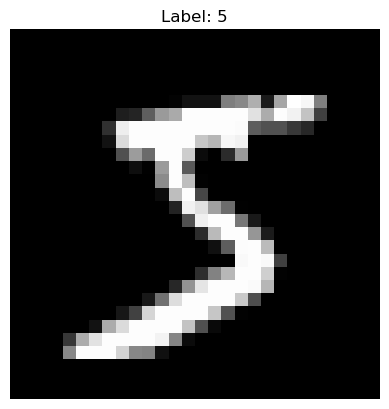

In [39]:
plt.imshow(X_train_small[0, :, :, 0], cmap="gray")
plt.title(f"Label: {y_train_small[0]}")
plt.axis("off")
plt.show()

In [40]:
model = CNN(learning_rate=0.01, epochs=1)

model._initialize_parameters(X_train_small[0].shape)

print("W1:", model.parameters["W1"].shape)
print("b1:", model.parameters["b1"].shape)
print("W2:", model.parameters["W2"].shape)
print("b2:", model.parameters["b2"].shape)

W1: (3, 3, 1, 2)
b1: (2,)
W2: (10, 338)
b2: (10, 1)


In [42]:
image = X_train_small[0]

probabilities, cache = model._forward(image)

print("Input:", image.shape)
print("Z1:", cache["Z1"].shape)
print("A1:", cache["A1"].shape)
print("A_pool:", cache["A_pool"].shape)
print("A_flat:", cache["A_flat"].shape)
print("Z2:", cache["Z2"].shape)
print("Probabilities:", probabilities.shape)

Input: (28, 28, 1)
Z1: (26, 26, 2)
A1: (26, 26, 2)
A_pool: (13, 13, 2)
A_flat: (338,)
Z2: (10, 1)
Probabilities: (10, 1)


## 9. MNIST training

Train the two-filter CNN for 10 epochs on the selected 2,000-image subset. The implementation updates parameters after each example, so this is sample-by-sample SGD rather than batch training.

## 8. MNIST forward-pass shape verification

Before training, inspect the intermediate tensors against the expected architecture: `(28, 28, 1) -> (26, 26, 2) -> (13, 13, 2) -> (338,) -> (10, 1)`.

In [48]:
model = CNN(learning_rate=0.01, epochs=10)

model.fit(X_train_small, Y_train_small)

y shape: (10, 1)
probabilities shape: (10, 1)
probabilities ndim: 2
dX_dense shape: (338, 1)
A_pool shape: (13, 13, 2)
A_pool ndim: 3
y shape: (10, 1)
probabilities shape: (10, 1)
probabilities ndim: 2
dX_dense shape: (338, 1)
A_pool shape: (13, 13, 2)
A_pool ndim: 3
y shape: (10, 1)
probabilities shape: (10, 1)
probabilities ndim: 2
dX_dense shape: (338, 1)
A_pool shape: (13, 13, 2)
A_pool ndim: 3
y shape: (10, 1)
probabilities shape: (10, 1)
probabilities ndim: 2
dX_dense shape: (338, 1)
A_pool shape: (13, 13, 2)
A_pool ndim: 3
y shape: (10, 1)
probabilities shape: (10, 1)
probabilities ndim: 2
dX_dense shape: (338, 1)
A_pool shape: (13, 13, 2)
A_pool ndim: 3
y shape: (10, 1)
probabilities shape: (10, 1)
probabilities ndim: 2
dX_dense shape: (338, 1)
A_pool shape: (13, 13, 2)
A_pool ndim: 3
y shape: (10, 1)
probabilities shape: (10, 1)
probabilities ndim: 2
dX_dense shape: (338, 1)
A_pool shape: (13, 13, 2)
A_pool ndim: 3
y shape: (10, 1)
probabilities shape: (10, 1)
probabilities nd

In [49]:
model.loss_history

[np.float64(1.0038735318828436),
 np.float64(0.4597760843306912),
 np.float64(0.39766389075134134),
 np.float64(0.3614498024954806),
 np.float64(0.33522886364573545),
 np.float64(0.31404134413300255),
 np.float64(0.29485867963049744),
 np.float64(0.27421065406703327),
 np.float64(0.25093606559304127),
 np.float64(0.22352448105606793)]

## 10. MNIST loss visualization

Plot the recorded epoch losses to make the training trajectory visible. The documented run decreases substantially over ten epochs, from about 1.00 to about 0.23.

In [50]:
test_accuracy = model.evaluate(X_test_small, Y_test_small)

print(f"Test accuracy: {test_accuracy:.2%}")

Test accuracy: 88.60%


## 11. Test evaluation

Evaluate on the held-out 500-image subset. The recorded experiment reached approximately 88.6% test accuracy with only two convolution filters.

In [51]:
print("Initial loss:", model.loss_history[0])
print("Final loss:", model.loss_history[-1])

Initial loss: 1.0038735318828436
Final loss: 0.22352448105606793


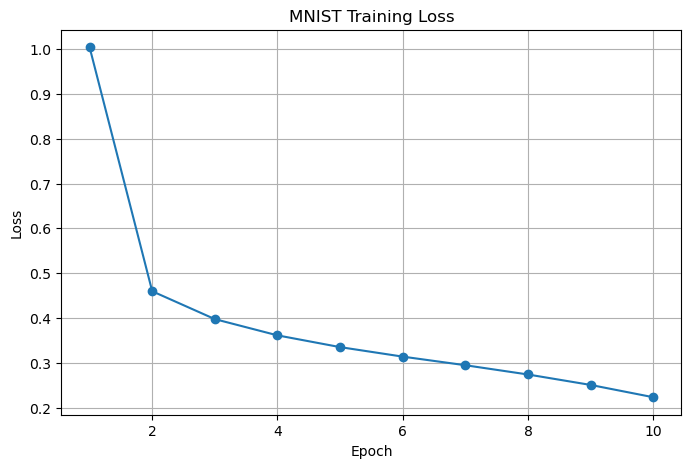

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(model.loss_history) + 1), model.loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training Loss")
plt.grid(True)
plt.show()

In [54]:
predictions = model.predict(X_test_small)
true_labels = np.argmax(Y_test_small, axis=0)

print("Correct:", np.sum(predictions == true_labels))
print("Total:", len(true_labels))
print("Accuracy:", np.mean(predictions == true_labels))

Correct: 443
Total: 500
Accuracy: 0.886


## 12. Misclassification analysis

Compare predicted and true labels, then visualize a sample of incorrect test images. These examples show where the small educational model still confuses visual patterns.

In [55]:
predictions = model.predict(X_test_small)
true_labels = np.argmax(Y_test_small, axis=0)

wrong_indices = np.where(predictions != true_labels)[0]

print("Number of incorrect predictions:", len(wrong_indices))
print("First 10 incorrect indices:", wrong_indices[:10])

Number of incorrect predictions: 57
First 10 incorrect indices: [ 1  8  9 33 44 46 65 66 80 87]


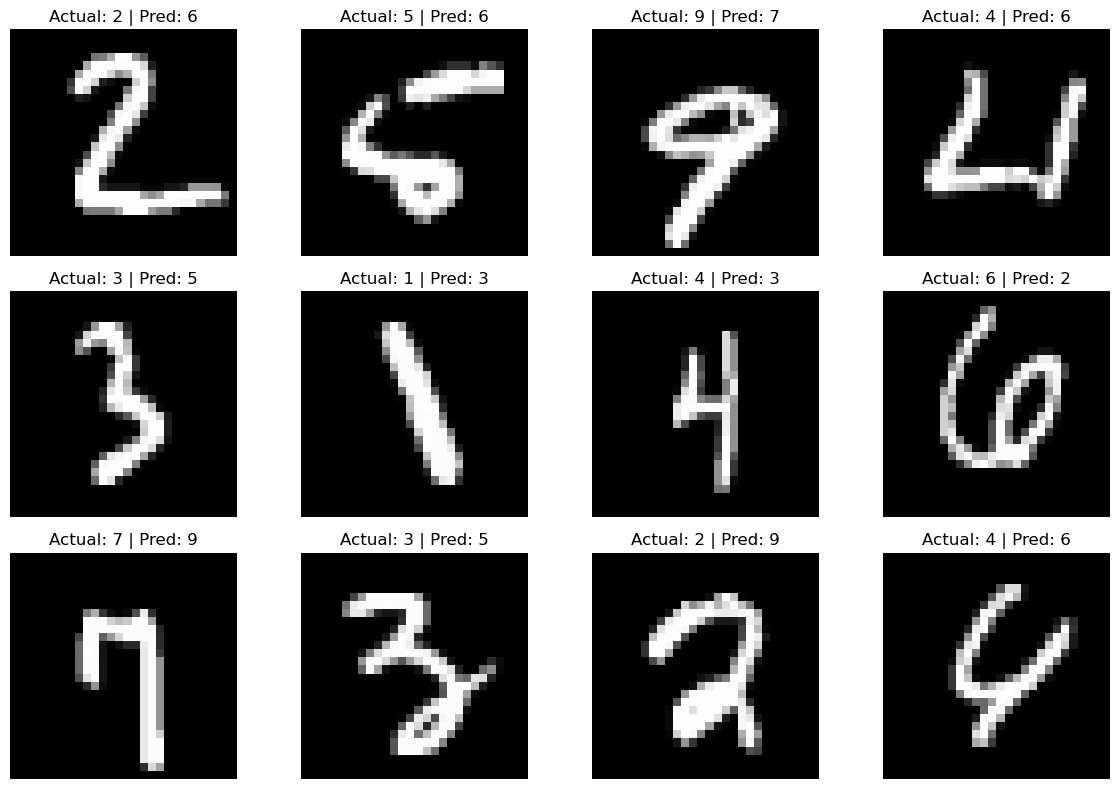

In [56]:

num_examples = 12

plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong_indices[:num_examples]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test_small[idx, :, :, 0], cmap="gray")

    plt.title(f"Actual: {true_labels[idx]} | " f"Pred: {predictions[idx]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
model.parameters["W1"]

array([[[[-0.06855774,  0.24902913]],

        [[ 0.31783476,  0.6363238 ]],

        [[-0.37901838,  0.82507457]]],


       [[[ 0.22637869, -0.36701428]],

        [[ 1.65912666, -0.2293925 ]],

        [[ 0.36909714,  0.12710716]]],


       [[[ 0.38381461, -0.56131355]],

        [[ 0.71934912, -0.58813926]],

        [[-0.00483006, -0.56033422]]]])

## 13. Learned convolution filters

Inspect the two learned first-layer filters. With grayscale MNIST input, each filter has shape `(3, 3, 1)` and represents a small spatial pattern discovered during training.

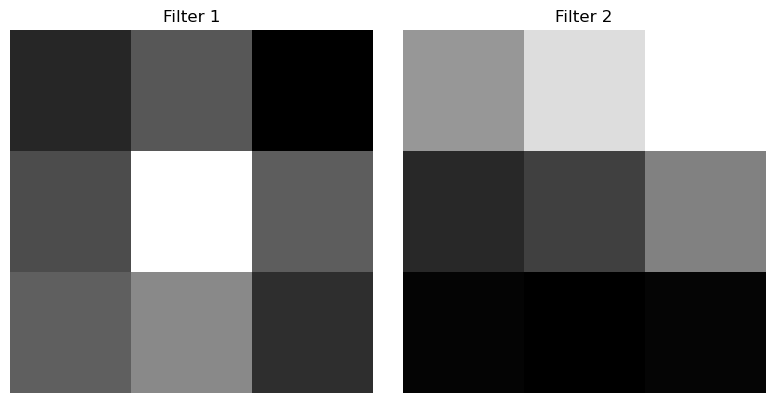

In [58]:
W1 = model.parameters["W1"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i in range(2):
    axes[i].imshow(W1[:, :, 0, i], cmap="gray")
    axes[i].set_title(f"Filter {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [59]:
image = X_test_small[0]

print("Actual digit:", true_labels[0])

Actual digit: 7


## 14. Feature-map visualization

Run one test image through the learned convolution and ReLU layers to visualize the two feature maps. This connects the learned weights to the intermediate visual representations used by the classifier.

In [61]:
from modules.module_01_cnn_foundations.implementations.convolution import (
    convolve_multifilter,
)

from modules.module_01_cnn_foundations.implementations.activations import relu

In [62]:
W1 = model.parameters["W1"]
b1 = model.parameters["b1"]

Z1 = convolve_multifilter(
    image,
    W1,
    b1,
    stride=1,
    padding=0,
)

A1 = relu(Z1)

print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)

Z1 shape: (26, 26, 2)
A1 shape: (26, 26, 2)


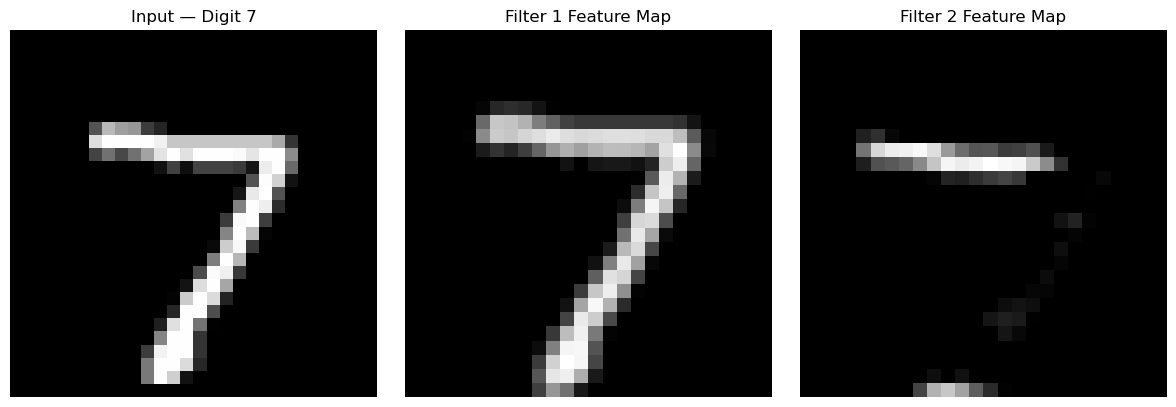

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image[:, :, 0], cmap="gray")
axes[0].set_title(f"Input — Digit {true_labels[0]}")
axes[0].axis("off")

axes[1].imshow(A1[:, :, 0], cmap="gray")
axes[1].set_title("Filter 1 Feature Map")
axes[1].axis("off")

axes[2].imshow(A1[:, :, 1], cmap="gray")
axes[2].set_title("Filter 2 Feature Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 15. Conclusions

This experiment demonstrates that the from-scratch NumPy implementation can train a small CNN on real image data. On the documented run, 2,000 training images and 500 test images produced approximately 88.6% test accuracy after 10 epochs with only two convolution filters.

The result confirms that the implementation learns useful visual structure, while the small fixed architecture, sample-by-sample SGD, and limited training subset explain why this should be treated as an educational baseline rather than a benchmark result.